## Tugas Praktikum Data Preprocessing

**Nama: Laura Aurelia  
NIM: 42324027  
Prodi: D3 Teknologi Informasi**

### BAGIAN A: PRAKTIKUM MISSING VALUE

In [1]:
import pandas as pd
path = "dataMissingValue.csv"
df = pd.read_csv(path)
df

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
2,C,High School,NaN,NaN,watermelon,NaN
3,D,High School,NaN,16.0,NaN,38.0
4,E,Middle School,B,15.0,banana,37.0
5,F,Middle School,NaN,14.0,grapes,NaN
6,G,Middle School,O,NaN,mango,36.0
7,H,High School,A,16.0,papaya,39.0
8,I,High School,NaN,18.0,NaN,40.0
9,J,Middle School,NaN,NaN,avocado,35.0


Data berhasil diimport, isinya data 10 murid dengan kolom Name, School Level, Blood Type, Age, Fav Fruit, dan Shoe Chart. Kelihatan ada beberapa nilai yang kosong (NaN) di beberapa kolom seperti Blood Type, Age, Fav Fruit, dan Shoe Chart. Data ini memang sengaja dibuat mengandung banyak missing value biar bisa dipakai latihan cara menanganinya.

In [2]:
df.isnull().sum()

Name            0
School Level    0
Blood Type      6
Age             3
Fav Fruit       2
Shoe Chart      2
dtype: int64

Perintah ini menghitung jumlah data yang hilang di setiap kolom. Hasilnya Blood Type kosong di 6 baris, Age kosong di 3 baris, Fav Fruit kosong di 2 baris, dan Shoe Chart kosong di 2 baris juga. Sedangkan Name dan School Level tidak ada yang kosong sama sekali. Ini langkah awal yang penting buat tau kualitas data sebelum diproses lebih lanjut.

In [3]:
percent_missing = 100*df.isnull().mean()
percent_missing

Name             0.0
School Level     0.0
Blood Type      60.0
Age             30.0
Fav Fruit       20.0
Shoe Chart      20.0
dtype: float64

Kalau tadi cuma jumlah baris yang kosong, sekarang dihitung persentasenya biar lebih kebayang seberapa parah datanya hilang. Blood Type ternyata kosong 60 persen, itu udah lumayan parah karena lebih dari separuh data. Age kosong 30 persen, Fav Fruit dan Shoe Chart masing masing 20 persen. Semakin besar persentasenya, biasanya semakin dipertimbangkan untuk dihapus kolomnya daripada diisi ulang, karena kalau diisi ulang malah bisa bikin data jadi kurang akurat.

In [4]:
df.dropna(axis=0)

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
4,E,Middle School,B,15.0,banana,37.0
7,H,High School,A,16.0,papaya,39.0


dropna dengan axis=0 artinya menghapus semua baris yang punya minimal satu nilai kosong. Hasilnya cuma tersisa 3 baris yaitu index 0, 4, dan 7, karena baris lainnya semua punya setidaknya satu kolom yang kosong. Cara ini simpel tapi boros banget, dari 10 baris data cuma tersisa 3, jadi kurang cocok dipakai kalau data yang hilang cukup banyak seperti kasus ini.

In [5]:
df.dropna(axis=1)

,Name,School Level
0,A,High School
1,B,High School
2,C,High School
3,D,High School
4,E,Middle School
5,F,Middle School
6,G,Middle School
7,H,High School
8,I,High School
9,J,Middle School


Kalau axis=1 artinya yang dihapus adalah kolomnya, bukan barisnya. Semua kolom yang punya nilai kosong langsung dibuang semua, jadi yang tersisa cuma Name dan School Level yang memang dari awal tidak ada missing value nya. Cara ini juga cukup ekstrem karena informasi dari 4 kolom lainnya jadi hilang semua.

In [12]:
df.dropna(thresh=5)

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
4,E,Middle School,B,15.0,banana,37.0
6,G,Middle School,O,NaN,mango,36.0
7,H,High School,A,16.0,papaya,39.0


thresh=5 artinya baris dipertahankan kalau minimal ada 5 nilai yang bukan kosong di baris itu. Jadi bukan mengecek satu kolom tertentu, tapi total keseluruhan nilai valid di baris tersebut. Contohnya baris index 2 kebuang karena di baris itu cuma ada 4 nilai yang valid, sisanya kosong, jadi tidak memenuhi syarat minimal 5. Cara ini lebih fleksibel dibanding dropna axis=0 biasa karena masih bisa mentolerir baris yang punya sedikit data kosong.

In [8]:
df.dropna(subset=['Age'])

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
3,D,High School,NaN,16.0,NaN,38.0
4,E,Middle School,B,15.0,banana,37.0
5,F,Middle School,NaN,14.0,grapes,NaN
7,H,High School,A,16.0,papaya,39.0
8,I,High School,NaN,18.0,NaN,40.0


Kalau pakai subset, kita bisa milih kolom tertentu aja yang jadi acuan penghapusan. Disini cuma baris yang kosong di kolom Age yang dibuang, walaupun baris itu ada kolom lain yang kosong juga tetap dipertahankan asal Age nya terisi. Ini berguna kalau ada satu kolom yang dianggap paling penting dan wajib ada isinya, sementara kolom lain masih bisa ditolerir kalau kosong.

In [9]:
df_drop = df.drop(columns = 'Blood Type')
df_drop

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,NaN
3,D,High School,16.0,NaN,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,NaN
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,NaN,40.0
9,J,Middle School,NaN,avocado,35.0


Karena tadi diketahui Blood Type kosong sampai 60 persen, kolom ini dianggap terlalu banyak data hilangnya untuk diisi ulang secara akurat, jadi lebih baik kolomnya langsung dibuang seluruhnya pakai drop. Hasilnya disimpan ke variabel baru df_drop yang sekarang cuma punya 5 kolom, tanpa Blood Type lagi.

In [10]:
df_filled = df_drop.copy()
df_filled['Age'] = df['Age'].fillna(df['Age'].mean())
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,NaN
3,D,High School,16.000000,NaN,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,NaN
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,NaN,40.0
9,J,Middle School,15.857143,avocado,35.0


fillna dipakai untuk mengisi nilai kosong, bukan menghapusnya. Disini kolom Age yang kosong diisi pakai nilai rata rata dari kolom Age itu sendiri, hasilnya sekitar 15.86. Cara ini disebut imputasi mean, cocok dipakai kalau datanya numerik dan sebarannya cukup normal, tidak terlalu banyak nilai ekstrem yang bisa bikin rata rata jadi bias.

In [13]:
df_filled['Shoe Chart'] = df['Shoe Chart'].fillna(df['Shoe Chart'].median())
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,37.5
3,D,High School,16.000000,NaN,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,37.5
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,NaN,40.0
9,J,Middle School,15.857143,avocado,35.0


Untuk kolom Shoe Chart, yang kosong diisi pakai median atau nilai tengah, hasilnya 37.5. Median biasanya dipilih kalau khawatir datanya ada outlier atau nilai ekstrem, karena median tidak terlalu terpengaruh sama nilai yang jauh berbeda dari yang lain, beda dengan mean yang gampang tertarik ke arah nilai ekstrem tersebut.

In [14]:
df_filled['Fav Fruit'] = df['Fav Fruit'].fillna(df['Fav Fruit'].mode().iloc[0])
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,37.5
3,D,High School,16.000000,banana,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,37.5
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,banana,40.0
9,J,Middle School,15.857143,avocado,35.0


Karena Fav Fruit isinya data kategorikal atau teks, bukan angka, jadi tidak bisa diisi pakai mean atau median. Solusinya pakai mode, yaitu nilai yang paling sering muncul. Disini yang kosong diisi dengan banana karena banana adalah buah yang paling sering disebut di data ini. Setelah tahap ini, df_filled sudah tidak punya missing value sama sekali di semua kolomnya.

In [15]:
df_filled2 = df_drop.copy()
df_filled2['Shoe Chart'] = df_filled2['Shoe Chart'].bfill()
df_filled2

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,38.0
3,D,High School,16.0,NaN,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,36.0
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,NaN,40.0
9,J,Middle School,NaN,avocado,35.0


Selain fillna dengan mean, median, atau mode, ada juga cara mengisi data kosong berdasarkan data di sekitarnya. bfill singkatan dari backward fill, artinya nilai kosong diisi pakai nilai dari baris setelahnya. Contohnya di Shoe Chart index 2 yang kosong diisi 38.0 karena itu nilai dari baris index 3 tepat di bawahnya.

In [16]:
df_filled2['Fav Fruit'] = df_filled2['Fav Fruit'].ffill()
df_filled2

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,38.0
3,D,High School,16.0,watermelon,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,36.0
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,papaya,40.0
9,J,Middle School,NaN,avocado,35.0


Kebalikan dari bfill, ffill singkatan dari forward fill, mengisi nilai kosong pakai nilai dari baris sebelumnya. Contohnya Fav Fruit index 3 yang kosong diisi watermelon karena itu nilai dari baris index 2 tepat di atasnya. Cara bfill dan ffill ini cocok dipakai kalau datanya berurutan secara waktu atau punya pola tertentu antar baris yang berdekatan, misalnya data deret waktu.

### BAGIAN B: PRAKTIKUM OUTLIERS

In [17]:
path = "weight-height_outlier.csv"
df2 = pd.read_csv(path)
df2

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


Dataset baru ini berisi 10000 baris data tinggi dan berat badan orang, dengan kolom Gender, Height, dan Weight. Dataset sebesar ini biasanya punya beberapa data ekstrem atau outlier yang perlu dideteksi dan ditangani sebelum dipakai untuk analisis lebih lanjut, karena outlier bisa bikin hasil analisis jadi menyesatkan.

<Axes: ylabel='Height'>

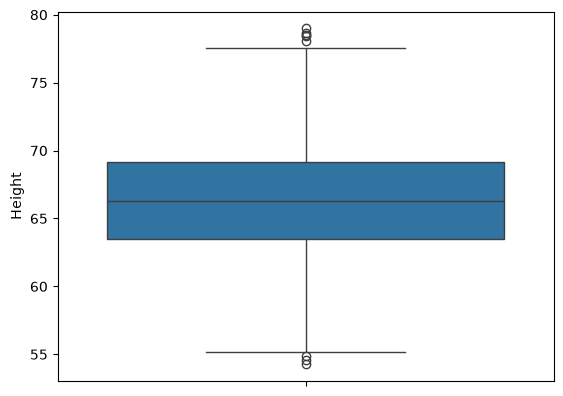

In [18]:
import seaborn as sns
sns.boxplot(df2['Height'])

Boxplot dipakai untuk melihat sebaran data secara visual. Kotak di tengah menunjukkan rentang Q1 sampai Q3, garis di tengah kotak menunjukkan median, dan garis yang menjulur di kedua sisi disebut whiskers. Titik titik yang berada di luar whiskers itulah yang dianggap sebagai outlier. Dari boxplot Height ini kelihatan ada beberapa titik yang letaknya jauh dari kelompok data utama.

<Axes: ylabel='Height'>

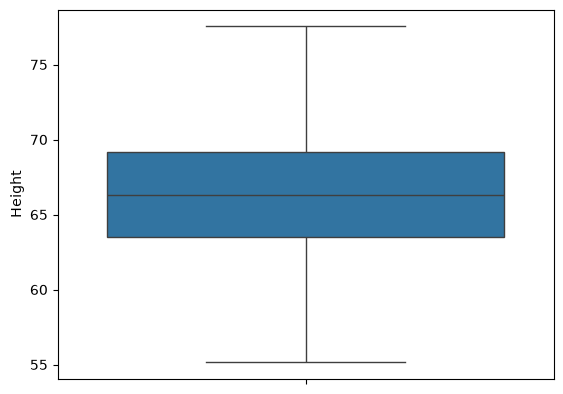

In [19]:
import numpy as np
q1, q3 = np.percentile(df2['Height'], [25, 75])
iqr = q3 - q1
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)
clean_data = df2[(df2['Height'] >= lower_bound) & (df2['Height'] <= upper_bound)]

sns.boxplot(clean_data['Height'])

Ini cara menghapus outlier pakai metode IQR atau interquartile range. Caranya, cari dulu Q1 dan Q3 nya, lalu hitung IQR yaitu selisih Q3 dikurangi Q1. Batas bawah dihitung dari Q1 dikurangi 1.5 kali IQR, dan batas atas dari Q3 ditambah 1.5 kali IQR. Data yang nilainya di luar batas bawah dan batas atas itu dianggap outlier dan dibuang. Setelah dibuang, boxplot yang baru kelihatan lebih rapi, sudah tidak ada lagi titik yang jauh dari kotak utama.

<Axes: ylabel='Weight'>

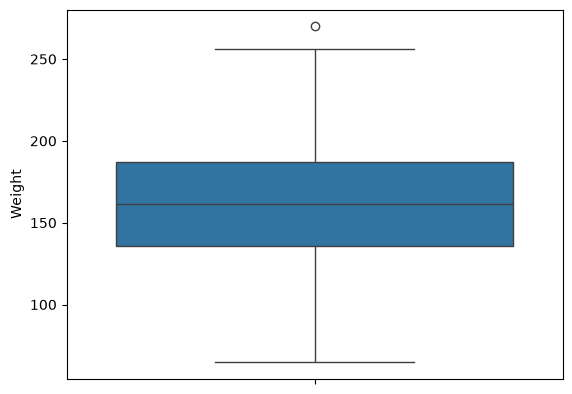

In [20]:
sns.boxplot(df2['Weight'])

<Axes: ylabel='Weight'>

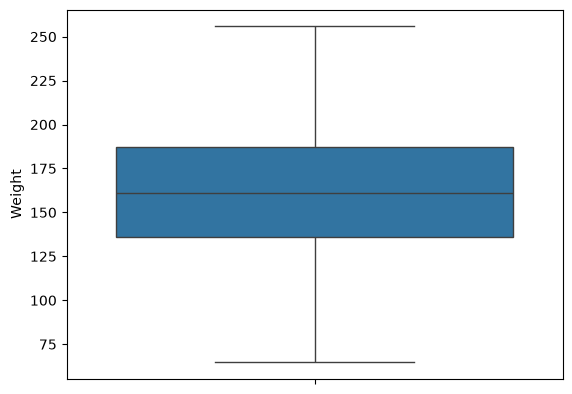

In [21]:
q1, q3 = np.percentile(df2['Weight'], [25, 75])
iqr = q3 - q1
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)
clean_data = df2[(df2['Weight'] >= lower_bound) & (df2['Weight'] <= upper_bound)]

sns.boxplot(clean_data['Weight'])

Langkah yang sama diulangi lagi tapi sekarang untuk kolom Weight. Prosesnya identik, cari Q1 Q3, hitung IQR, tentukan batas bawah dan atas, lalu buang data yang di luar batas itu. Kolom Height dan Weight ini masing masing punya outlier yang berbeda, jadi perlu dicek dan dibersihkan satu per satu.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19412\784671581.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df2[col], vert=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_19412\784671581.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df2[col], vert=False)


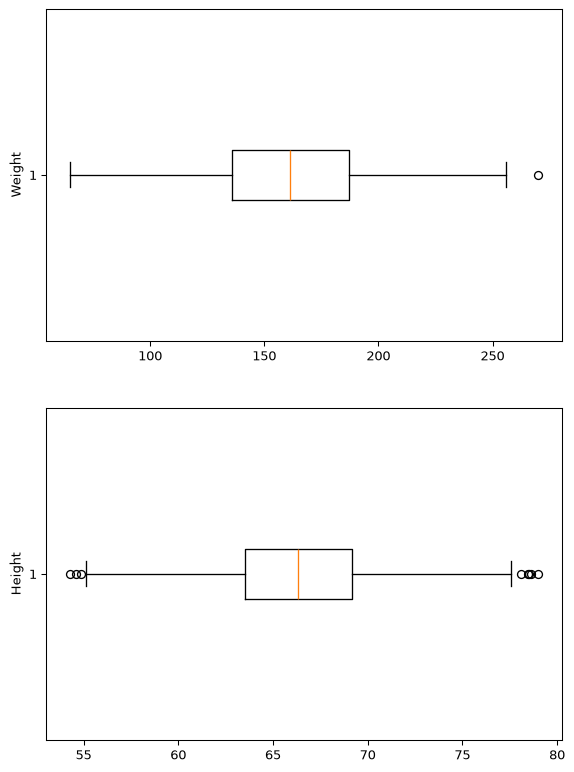

In [22]:
import matplotlib.pyplot as plt

columns_to_plot = ['Weight', 'Height']
columns_to_plot = [col for col in columns_to_plot if col in df2.columns]

fig, axs = plt.subplots(len(columns_to_plot), 1, dpi=95, figsize=(7, 5 * len(columns_to_plot)))

if len(columns_to_plot) == 1:
    axs = [axs]

for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(df2[col], vert=False)
    axs[i].set_ylabel(col)

plt.show()

Selain seaborn, boxplot juga bisa dibuat pakai matplotlib langsung. Disini dibuat dua boxplot sekaligus dalam satu figure, satu untuk Weight dan satu untuk Height, biar bisa dibandingkan dalam satu tampilan. Fungsi vert=False bikin boxplotnya horizontal, jadi lebih gampang dibaca outlier nya yang menyebar ke kanan.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19412\311436384.py:20: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_data[col], vert=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_19412\311436384.py:20: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_data[col], vert=False)


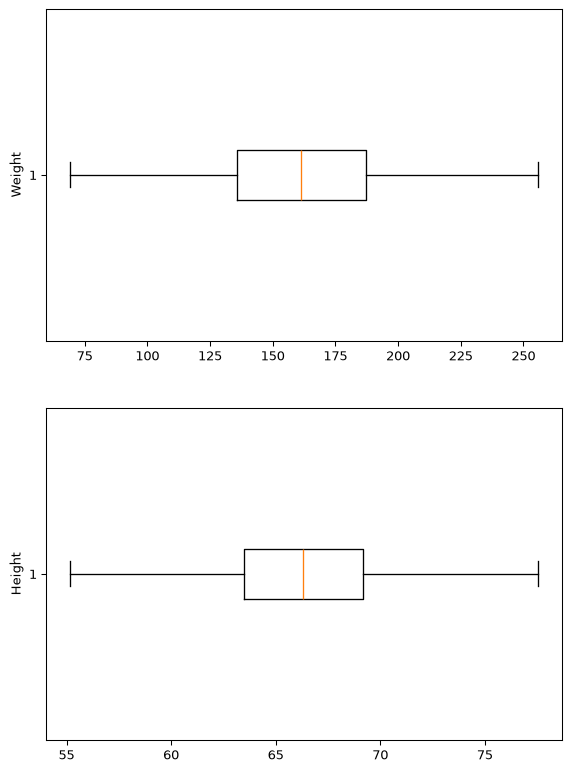

In [23]:
def remove_outliers_sequentially(df2, columns):
    df_cleaned = df2.copy()
    for col in columns:
        q1, q3 = np.percentile(df_cleaned[col], [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)
        df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]
    return df_cleaned

clean_data = remove_outliers_sequentially(df2, ['Height', 'Weight'])

columns_to_plot = ['Weight', 'Height']
fig, axs = plt.subplots(len(columns_to_plot), 1, dpi=95, figsize=(7, 5 * len(columns_to_plot)))

if len(columns_to_plot) == 1:
    axs = [axs]

for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(clean_data[col], vert=False)
    axs[i].set_ylabel(col)

plt.show()

Daripada bersihin kolom satu satu secara manual kayak tadi, dibikin fungsi remove_outliers_sequentially biar bisa langsung membersihkan beberapa kolom sekaligus secara berurutan. Fungsi ini menerima daftar kolom, terus untuk tiap kolom dihitung batas IQR nya dan langsung dibuang baris yang di luar batas itu. Setelah diterapkan ke Height dan Weight, data awal yang tadinya 10000 baris berkurang jadi 9992 baris, artinya total 8 baris yang kebuang karena dianggap outlier di salah satu atau kedua kolom itu.

In [24]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

numeric_cols = clean_data.select_dtypes(include=[np.number]).columns
non_numeric_cols = clean_data.select_dtypes(exclude=[np.number]).columns

rescaled_numeric = scaler.fit_transform(clean_data[numeric_cols])
rescaled_numeric[:]

array([[0.83480376, 0.92524773],
       [0.6086688 , 0.49939825],
       [0.84654949, 0.76925146],
       ...,
       [0.38928431, 0.31834619],
       [0.61993463, 0.50764944],
       [0.30339752, 0.23901104]], shape=(9992, 2))

Setelah outlier dibersihkan, langkah selanjutnya biasanya normalisasi data pakai MinMaxScaler, supaya semua kolom numerik punya skala yang sama, dalam kasus ini antara 0 sampai 1. Ini penting soalnya Height dan Weight punya satuan dan rentang yang beda jauh, kalau tidak dinormalisasi nanti bisa bikin model machine learning jadi lebih berat ke salah satu kolom yang angkanya lebih besar.

In [25]:
rescaled_df = pd.DataFrame(rescaled_numeric, columns=numeric_cols, index=clean_data.index)
final_df = pd.concat([clean_data[non_numeric_cols], rescaled_df], axis=1)
final_df

,Gender,Height,Weight
0,Male,0.834804,0.925248
1,Male,0.608669,0.499398
2,Male,0.846549,0.769251
3,Male,0.740332,0.808322
4,Male,0.657774,0.735053
...,...,...,...
9995,Female,0.492177,0.362771
9996,Female,0.532113,0.545189
9997,Female,0.389284,0.318346
9998,Female,0.619935,0.507649


Hasil normalisasi tadi masih berupa array biasa, jadi diubah balik jadi DataFrame supaya lebih gampang dibaca, terus digabung lagi sama kolom non numerik yaitu Gender yang sempat dipisah. Hasil akhirnya final_df ini sudah bersih dari outlier dan sudah dinormalisasi, siap dipakai untuk tahap selanjutnya kayak training model machine learning.

# Tugas Praktikum Week 02 Sesi 03

### TUGAS 2: Handling Missing Value dari Titanic-Dataset.csv

In [3]:
import pandas as pd

In [4]:
titanic = pd.read_csv("Titanic-Dataset.csv")
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Dataset Titanic ini punya 891 baris dan 12 kolom. Dari hasil pengecekan, ada 3 kolom yang punya missing value, yaitu Age kosong di 177 baris atau sekitar 19.9 persen, Cabin kosong di 687 baris atau sekitar 77.1 persen, dan Embarked kosong cuma di 2 baris atau 0.2 persen. Ketiga kolom ini punya tingkat kekosongan yang beda jauh, jadi caranya menangani juga perlu dibedakan satu satu.

In [5]:
titanic_clean = titanic.drop(columns='Cabin')

Kolom Cabin kosong sampai 77 persen, itu udah kelewat banyak buat diisi ulang, kalau dipaksa diisi malah bakal bikin data jadi tidak akurat karena kebanyakan nilainya cuma tebakan. Jadi pilihan paling masuk akal buat kolom ini ya langsung dibuang aja seluruh kolomnya.

In [6]:
titanic_clean['Age'] = titanic_clean['Age'].fillna(titanic_clean['Age'].median())

Untuk kolom Age yang kosong sekitar 20 persen, masih cukup masuk akal buat diisi ulang daripada dibuang. Dipilih median bukan mean, soalnya umur itu biasanya sebarannya agak miring, ada penumpang bayi sampai orang tua, jadi median lebih aman dipakai karena tidak gampang tertarik sama nilai umur yang ekstrem dibanding mean.

In [7]:
titanic_clean['Embarked'] = titanic_clean['Embarked'].fillna(titanic_clean['Embarked'].mode().iloc[0])

Kolom Embarked isinya kode pelabuhan keberangkatan, jadi kategorikal bukan angka, makanya tidak bisa diisi pakai mean atau median. Karena yang kosong cuma 2 baris doang, sangat wajar diisi pakai mode atau nilai yang paling sering muncul, resikonya juga kecil karena cuma mempengaruhi 2 baris dari 891 baris total.

In [8]:
titanic_clean.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Setelah ketiga langkah di atas dijalankan, hasil pengecekan ulang menunjukkan semua kolom sudah tidak punya missing value lagi, semuanya menunjukkan angka 0. Ini artinya proses handling missing value untuk dataset Titanic sudah selesai dan datanya siap dipakai untuk analisis atau pemodelan selanjutnya.

### TUGAS 3: Handling Outliers dari diabetes.csv

In [9]:
diabetes = pd.read_csv("diabetes.csv")
diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Dataset diabetes ini punya 768 baris dan 9 kolom, berisi data medis pasien yang dipakai buat memprediksi apakah seseorang kena diabetes atau tidak. Untuk deteksi outlier kali ini dipilih 3 kolom yaitu Insulin, SkinThickness, dan BMI. Ketiga kolom ini dipilih karena dari hasil describe kelihatan rentang nilai minimal dan maksimalnya cukup jauh dibanding kolom lain, jadi berpotensi punya banyak data ekstrem.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9616\2553245210.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(diabetes[col], vert=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_9616\2553245210.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(diabetes[col], vert=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_9616\2553245210.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(diabetes[col], vert=False)


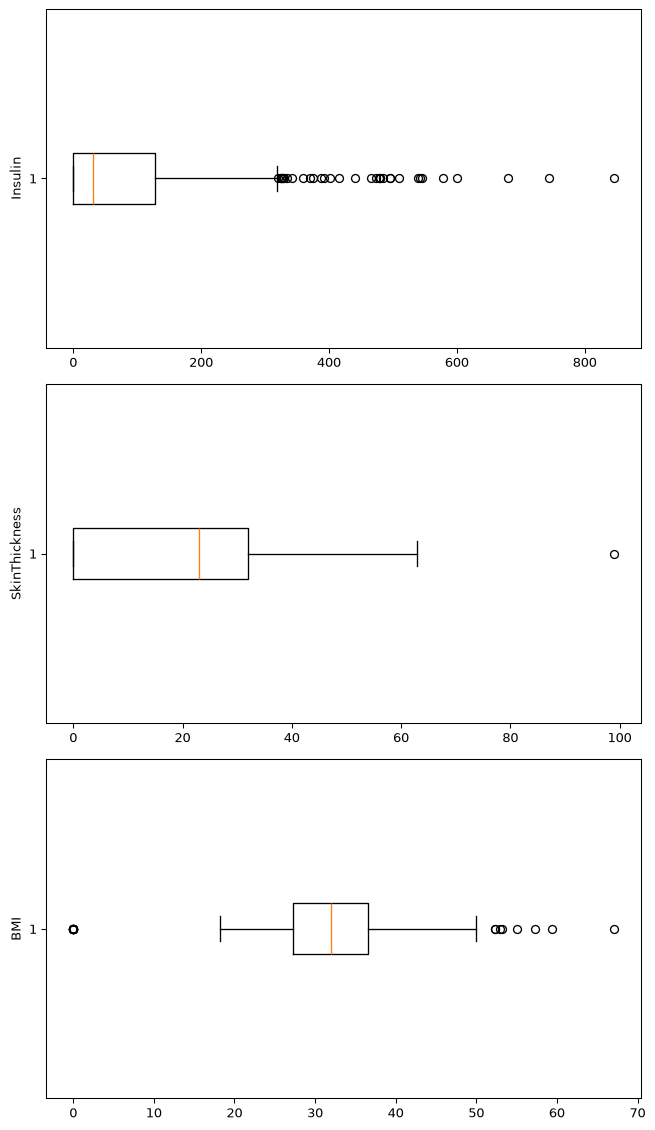

In [10]:
import matplotlib.pyplot as plt

columns_to_plot = ['Insulin', 'SkinThickness', 'BMI']

fig, axs = plt.subplots(len(columns_to_plot), 1, dpi=95, figsize=(7, 4 * len(columns_to_plot)))

for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(diabetes[col], vert=False)
    axs[i].set_ylabel(col)

plt.tight_layout()
plt.show()

Dari boxplot yang dihasilkan, Insulin kelihatan paling parah, banyak banget titik yang menyebar jauh ke kanan, bahkan sampai ratusan padahal kebanyakan data lain nilainya kecil. SkinThickness juga ada satu titik yang jauh sendiri di atas 90an sementara mayoritas data ada di bawah 40. BMI juga ada beberapa titik ekstrem baik yang terlalu rendah mendekati 0 maupun yang terlalu tinggi di atas 50.

In [11]:
import numpy as np

def remove_outliers_sequentially(df, columns):
    df_cleaned = df.copy()
    for col in columns:
        q1, q3 = np.percentile(df_cleaned[col], [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)
        df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]
    return df_cleaned

diabetes_clean = remove_outliers_sequentially(diabetes, columns_to_plot)
print("jumlah baris sebelum dibersihkan:", diabetes.shape[0])
print("jumlah baris sesudah dibersihkan:", diabetes_clean.shape[0])

jumlah baris sebelum dibersihkan: 768
jumlah baris sesudah dibersihkan: 715


Pakai metode IQR yang sama kayak di praktikum, outlier dari ketiga kolom itu dibuang secara berurutan. Hasilnya jumlah baris berkurang dari 768 jadi 715, artinya ada 53 baris yang kebuang karena dianggap outlier di salah satu dari kolom Insulin, SkinThickness, atau BMI.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9616\503404892.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(diabetes_clean[col], vert=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_9616\503404892.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(diabetes_clean[col], vert=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_9616\503404892.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(diabetes_clean[col], vert=False)


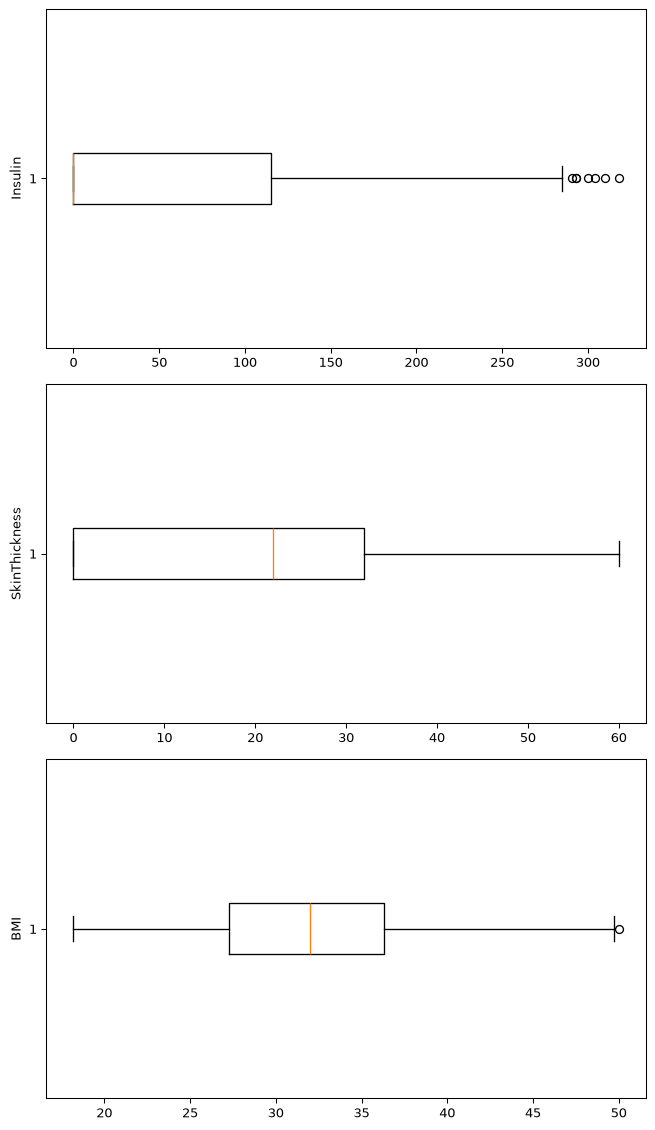

In [12]:
fig, axs = plt.subplots(len(columns_to_plot), 1, dpi=95, figsize=(7, 4 * len(columns_to_plot)))

for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(diabetes_clean[col], vert=False)
    axs[i].set_ylabel(col)

plt.tight_layout()
plt.show()

Setelah dibersihkan, boxplot ketiga kolom ini kelihatan jauh lebih rapi, titik titik yang tadinya menyebar jauh dari kotak utama sekarang udah tidak ada lagi. Insulin yang tadinya sampai 800an sekarang batas atasnya udah lebih wajar di sekitar 300an. Ini nunjukin data yang dipakai sekarang lebih representatif buat dipakai analisis atau training model, karena udah tidak ada lagi nilai yang bisa bikin hasil perhitungan jadi bias gara gara pengaruh data ekstrem.